## Pre testing (movies)

Here before trying a combination of multiple models, we will define a foundation on how we will run our models.

In [1]:
from preprocessing_class import Preprocessing, load_movies
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [2]:
# load dataset
alltxt, alllabs = load_movies("./Dataset/movies1000/")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)

len(alltxt), len(alllabs), np.unique(alllabs)

(2000, 2000, array([0, 1]))

In [3]:
# train test split here for test in final prediction

X_train, X_test, y_train, y_test = train_test_split(
    alltxt, alllabs, 
    test_size=0.20, 
    random_state=42
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.20, 
    random_state=42
)

len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(1280, 1280, 320, 320, 1600, 1600, 400, 400)

### 1.Training time based on vocabulary size, for different modèles

In [4]:
prep = Preprocessing(low_case = True,
        rm_punctuation = True,
        rm_number = False,
        word_norm = None, # stem faster
        pos_tagging = False, # to check
        all_capital = True, # keep all capital words as they are
        cap_name = True, # garder les noms en majuscules, for pos tag
        rm_accent = True, 
        lang = "english",
        punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
        urls = False 
    )


In [5]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier

final_stopwords_list = stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "rf":
        return RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    elif name == "linear_svm":
        return LinearSVC(class_weight="balanced", penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "nb":
        return MultinomialNB()
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(class_weight="balanced", solver=solver,max_iter=max_iter) 

In [8]:
# this time with cv on the train 
import time
import gc
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_time = {}
val_f1     = {}
val_acc     = {}
val_rec    = {}
val_prec      = {}

max_features_test = [500, 1000, 5000, 10000,15000,20000]
models_names      = ["logreg", "linear_svm", "nb", "rf"]

for max_feat in max_features_test:
    print(f"\n--- max_features = {max_feat} ---")
    train_time[max_feat] = {}
    val_f1[max_feat]     = {}
    val_acc[max_feat]     = {}
    val_rec[max_feat]    = {}
    val_prec[max_feat]      = {}

    for model_name in models_names:
        needs_dense = model_name == "nb"
        times, f1s, accs, recs, precs = [], [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

            # fit vectorizer on fold train only — no leakage
            vectoriser = build_vectorizer(
                name="count",
                stop_words=final_stopwords_list,
                max_features=max_feat,
                preprocessor=prep
            )
            X_tr = vectoriser.fit_transform(X_train_fold)
            X_v  = vectoriser.transform(X_val_fold)
            print("size vocab", len(vectoriser.get_feature_names_out()))

            if needs_dense:
                X_tr = X_tr.toarray()
                X_v  = X_v.toarray()

            model = build_model(name=model_name, max_iter=2000)

            start_time = time.time()
            model.fit(X_tr, y_train_fold)
            elapsed = time.time() - start_time

            y_pred_val  = model.predict(X_v)
            y_score_val = (
                model.predict_proba(X_v)[:, 1]
                if needs_dense or hasattr(model, "predict_proba")
                else model.decision_function(X_v)
            )

            times.append(elapsed)
            f1s.append(f1_score(y_val_fold, y_pred_val))
            accs.append(accuracy_score(y_val_fold, y_pred_val))
            recs.append(recall_score(y_val_fold, y_pred_val))
            precs.append(precision_score(y_val_fold, y_pred_val))


            del vectoriser, model, X_tr, X_v, y_pred_val, y_score_val
            gc.collect()

        train_time[max_feat][model_name] = times
        val_f1[max_feat][model_name]     = f1s
        val_acc[max_feat][model_name]     = accs
        val_rec[max_feat][model_name]    = recs
        val_prec[max_feat][model_name]      = precs

        print(f"  {model_name}:"
              f"  time={np.mean(times):.3f}±{np.std(times):.3f}s"
              f"  F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}"
              f"  Acc={np.mean(accs):.4f}±{np.std(accs):.4f}"
              f"  Rec={np.mean(recs):.4f}±{np.std(recs):.4f}"
              f"  Prec={np.mean(precs):.4f}±{np.std(precs):.4f}")


--- max_features = 500 ---
size vocab 500
size vocab 500
size vocab 500
size vocab 500
size vocab 500
  logreg:  time=0.061±0.003s  F1=0.7447±0.0263  Acc=0.7444±0.0285  Rec=0.7460±0.0282  Prec=0.7444±0.0366
size vocab 500
size vocab 500
size vocab 500
size vocab 500
size vocab 500
  linear_svm:  time=0.226±0.026s  F1=0.7292±0.0270  Acc=0.7269±0.0293  Rec=0.7359±0.0348  Prec=0.7240±0.0379
size vocab 500
size vocab 500
size vocab 500
size vocab 500
size vocab 500
  nb:  time=0.004±0.000s  F1=0.7663±0.0174  Acc=0.7675±0.0167  Rec=0.7634±0.0222  Prec=0.7696±0.0207
size vocab 500
size vocab 500
size vocab 500
size vocab 500
size vocab 500
  rf:  time=1.406±0.020s  F1=0.7433±0.0054  Acc=0.7444±0.0103  Rec=0.7409±0.0165  Prec=0.7466±0.0205

--- max_features = 1000 ---
size vocab 1000
size vocab 1000
size vocab 1000
size vocab 1000
size vocab 1000
  logreg:  time=0.057±0.004s  F1=0.7941±0.0241  Acc=0.7925±0.0260  Rec=0.8011±0.0349  Prec=0.7890±0.0362
size vocab 1000
size vocab 1000
size vocab

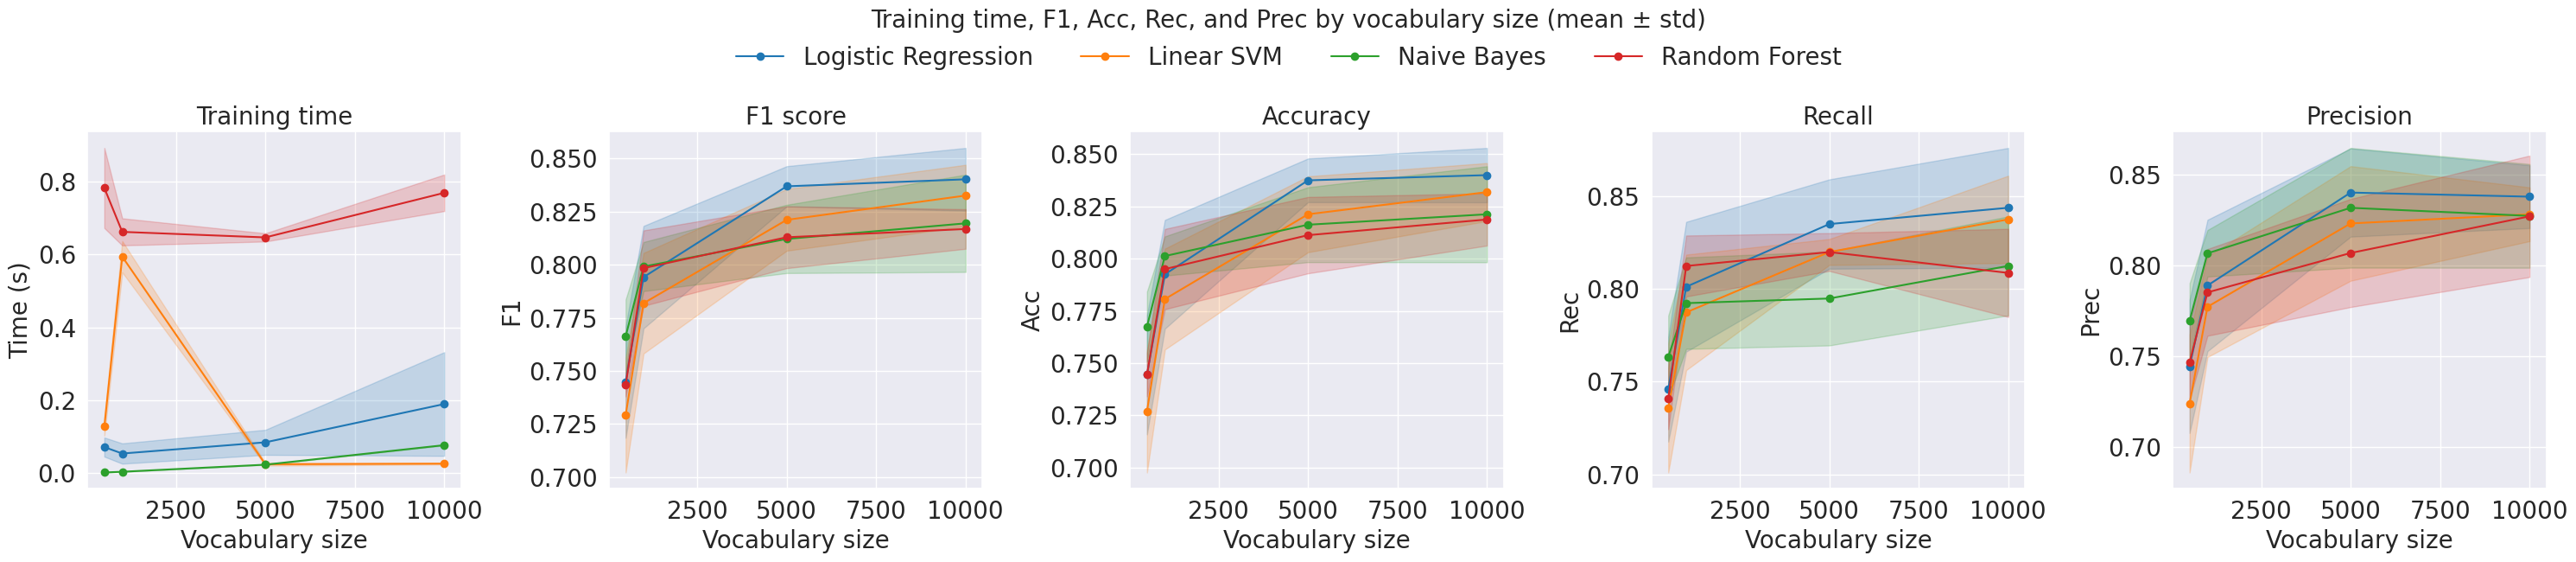

'\nfig, axes = plt.subplots(1, 5, figsize=(30, 6))\n\npalette = sns.color_palette("tab10", n_colors=len(models_names))\n\nfor i, (model_name, color) in enumerate(zip(models_names, palette)):\n    label = label_map.get(model_name, model_name)\n\n    data = [\n        (train_time, val_f1, val_acc, val_rec, val_prec)\n    ]\n\n    for ax, (metric_dict, title, ylabel) in zip(axes, metrics):\n        mean_vals = np.array([np.mean(metric_dict[mf][model_name]) for mf in max_features_test])\n        std_vals  = np.array([np.std(metric_dict[mf][model_name])  for mf in max_features_test])\n\n        ax.plot(max_features_test, mean_vals, marker="o", label=label, color=color)\n        ax.fill_between(\n            max_features_test,\n            mean_vals - std_vals,\n            mean_vals + std_vals,\n            alpha=0.2,\n            color=color,\n        )\n\n\nfor ax, (_, title, ylabel) in zip(axes, metrics):\n    ax.set_title(title)\n    ax.set_xlabel("Vocabulary size")\n    ax.set_ylabel(y

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

metrics = [
    (train_time, "Training time", "Time (s)"),
    (val_f1,     "F1 score",      "F1"),
    (val_acc,     "Accuracy", "Acc"),
    (val_rec,    "Recall",     "Rec"),
    (val_prec,      "Precision",      "Prec"),
]

label_map = {
    "nb":         "Naive Bayes",
    "logreg":     "Logistic Regression",
    "linear_svm": "Linear SVM",
    "rf":         "Random Forest",
}

palette = sns.color_palette("tab10", n_colors=len(models_names))
fig, axes = plt.subplots(1, 5, figsize=(30,6))

for i, (model_name, color) in enumerate(zip(models_names, palette)):
    label = label_map.get(model_name, model_name)

    data = [
        (train_time, val_f1, val_acc, val_rec, val_prec)
    ]

    for ax, (metric_dict, title, ylabel) in zip(axes, metrics):
        mean_vals = np.array([np.mean(metric_dict[mf][model_name]) for mf in max_features_test])
        std_vals  = np.array([np.std(metric_dict[mf][model_name])  for mf in max_features_test])

        ax.plot(max_features_test, mean_vals, marker="o", label=label, color=color)
        ax.fill_between(
            max_features_test,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2,
            color=color,
        )

for ax, (_, title, ylabel) in zip(axes, metrics):
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Vocabulary size", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)

# shared legend on top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=20)

plt.suptitle("Training time, F1, Acc, Rec, and Prec by vocabulary size (mean ± std)", y=1.08, fontsize=20)
plt.tight_layout()
plt.savefig("images/pretest/training_time_f1_acc_rec_prec_by_vocab_size_5.pdf", bbox_inches="tight")
plt.show()


### 2. Cross validation vs split

In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
import numpy as np
import gc

n_runs   = 20
max_feat = 5000

# ── 1. Repeated hold-out ──────────────────────────────────────────────────────
split_f1_scores  = []
split_acc_scores = []
split_rec_scores = []
split_prec_scores = []

for seed in range(n_runs):
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_train, y_train,
        test_size=0.2,
        random_state=seed,
    )
    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep,
    )
    X_train_vec = vectoriser.fit_transform(X_train_sub)
    X_test_vec  = vectoriser.transform(X_test_sub)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_sub)

    y_score = model.decision_function(X_test_vec)
    y_pred  = model.predict(X_test_vec)

    split_f1_scores.append(f1_score(y_test_sub, y_pred))
    split_acc_scores.append(accuracy_score(y_test_sub, y_pred))
    split_rec_scores.append(recall_score(y_test_sub, y_pred))
    split_prec_scores.append(precision_score(y_test_sub, y_pred))

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

split_f1_scores  = np.array(split_f1_scores)
split_acc_scores = np.array(split_acc_scores)
split_rec_scores = np.array(split_rec_scores)
split_prec_scores = np.array(split_prec_scores)

print("Repeated hold-out (20 runs)")
print(f"  F1  — mean: {split_f1_scores.mean():.4f}  std: {split_f1_scores.std():.4f}  scores: {np.round(split_f1_scores, 4)}")
print(f"  Acc — mean: {split_acc_scores.mean():.4f}  std: {split_acc_scores.std():.4f}  scores: {np.round(split_acc_scores, 4)}")
print(f"  Rec — mean: {split_rec_scores.mean():.4f}  std: {split_rec_scores.std():.4f}  scores: {np.round(split_rec_scores, 4)}")
print(f"  Prec — mean: {split_prec_scores.mean():.4f}  std: {split_prec_scores.std():.4f}  scores: {np.round(split_prec_scores, 4)}")

# ── 2. Stratified K-Fold CV ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_f1_scores  = []
cv_acc_scores = []
cv_rec_scores = []
cv_prec_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_test_fold  = X_train[test_idx]
    y_test_fold  = y_train[test_idx]

    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep,
    )
    X_train_vec = vectoriser.fit_transform(X_train_fold)
    X_test_vec  = vectoriser.transform(X_test_fold)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_fold)

    y_score = model.decision_function(X_test_vec)
    y_pred  = model.predict(X_test_vec)

    cv_f1_scores.append(f1_score(y_test_fold, y_pred))
    cv_acc_scores.append(accuracy_score(y_test_fold, y_pred))
    cv_rec_scores.append(recall_score(y_test_fold, y_pred))
    cv_prec_scores.append(precision_score(y_test_fold, y_pred))


    print(f"  Fold {fold_idx}/5 — : F1: {cv_f1_scores[-1]:.4f}  Acc: {cv_acc_scores[-1]:.4f}  Rec: {cv_rec_scores[-1]:.4f}  Prec: {cv_prec_scores[-1]:.4f}")

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

cv_acc_scores = np.array(cv_acc_scores)
cv_f1_scores  = np.array(cv_f1_scores)
cv_rec_scores = np.array(cv_rec_scores)
cv_prec_scores = np.array(cv_prec_scores)

print("\nStratified 5-fold CV")
print(f"  Acc — mean: {cv_acc_scores.mean():.4f}  std: {cv_acc_scores.std():.4f}  scores: {np.round(cv_acc_scores, 4)}")
print(f"  F1  — mean: {cv_f1_scores.mean():.4f}  std: {cv_f1_scores.std():.4f}  scores: {np.round(cv_f1_scores, 4)}")
print(f"  Rec — mean: {cv_rec_scores.mean():.4f}  std: {cv_rec_scores.std():.4f}  scores: {np.round(cv_rec_scores, 4)}")
print(f"  Prec — mean: {cv_prec_scores.mean():.4f}  std: {cv_prec_scores.std():.4f}  scores: {np.round(cv_prec_scores, 4)}")

Repeated hold-out (20 runs)
  F1  — mean: 0.8284  std: 0.0167  scores: [0.8485 0.7925 0.8158 0.8383 0.8491 0.8282 0.8103 0.8246 0.8318 0.8529
 0.8308 0.8274 0.822  0.8475 0.8141 0.8075 0.8481 0.8094 0.8478 0.8211]
  Acc — mean: 0.8281  std: 0.0148  scores: [0.8438 0.7938 0.825  0.8469 0.85   0.825  0.8156 0.8219 0.8281 0.8438
 0.8281 0.8344 0.8281 0.8312 0.8188 0.8062 0.85   0.8219 0.8406 0.8094]
  Rec — mean: 0.8225  std: 0.0273  scores: [0.8284 0.7826 0.8052 0.8355 0.8491 0.8491 0.84   0.7791 0.8553 0.848
 0.8182 0.7888 0.8301 0.8197 0.8301 0.7602 0.8375 0.8176 0.8659 0.8092]
  Prec — mean: 0.8356  std: 0.0283  scores: [0.8696 0.8025 0.8267 0.8411 0.8491 0.8084 0.7826 0.8758 0.8095 0.858
 0.8438 0.8699 0.8141 0.8772 0.7987 0.8609 0.859  0.8013 0.8304 0.8333]
  Fold 1/5 — : F1: 0.8489  Acc: 0.8531  Rec: 0.8302  Prec: 0.8684
  Fold 2/5 — : F1: 0.8333  Acc: 0.8313  Rec: 0.8438  Prec: 0.8232
  Fold 3/5 — : F1: 0.8141  Acc: 0.8187  Rec: 0.7937  Prec: 0.8355
  Fold 4/5 — : F1: 0.8350  Acc:

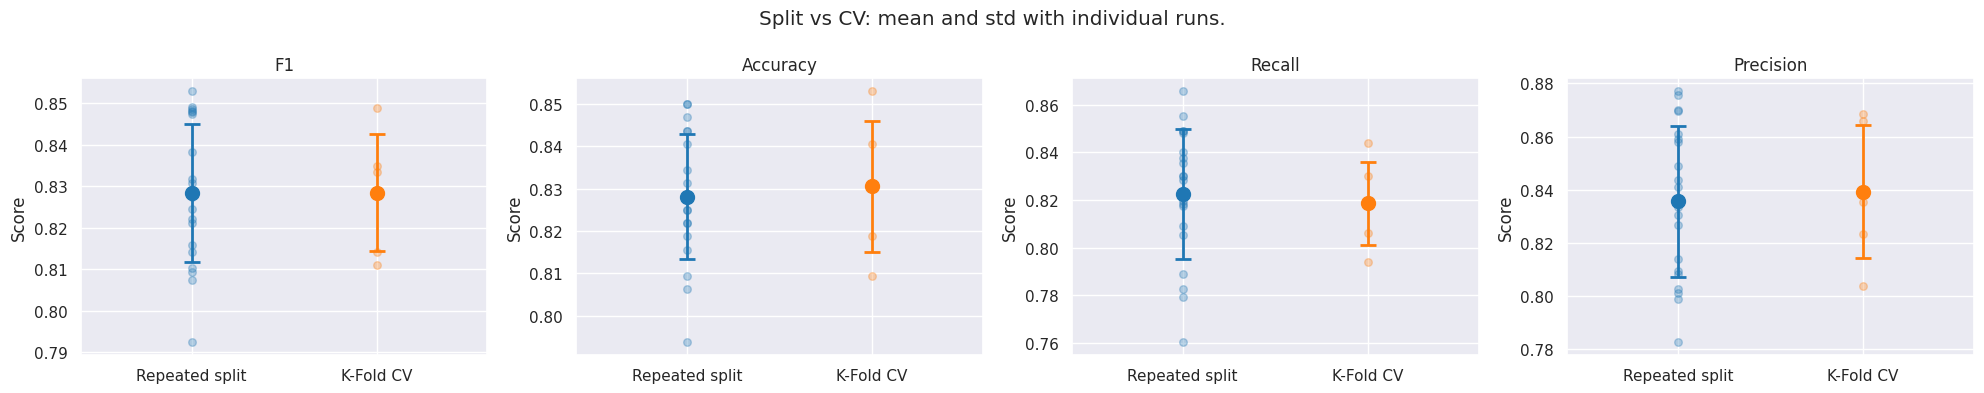

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
palette = sns.color_palette("tab10")

metrics     = ["F1", "Accuracy", "Recall", "Precision"]
split_means = [split_f1_scores.mean(), split_acc_scores.mean(), split_rec_scores.mean(), split_prec_scores.mean()]
split_stds  = [split_f1_scores.std(),  split_acc_scores.std(),  split_rec_scores.std(),  split_prec_scores.std()]
cv_means    = [cv_f1_scores.mean(),    cv_acc_scores.mean(),    cv_rec_scores.mean(),    cv_prec_scores.mean()]
cv_stds     = [cv_f1_scores.std(),     cv_acc_scores.std(),     cv_rec_scores.std(),     cv_prec_scores.std()]

score_map = {
    "F1":                (split_f1_scores,  cv_f1_scores),
    "Accuracy":          (split_acc_scores,  cv_acc_scores),
    "Recall":            (split_rec_scores,  cv_rec_scores),
    "Precision":         (split_prec_scores,  cv_prec_scores),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

for ax, metric, s_mean, s_std, cv_mean, cv_std in zip(
        axes, metrics, split_means, split_stds, cv_means, cv_stds):

    split_scores, cv_scores = score_map[metric]

    ax.scatter(np.zeros(len(split_scores)), split_scores,
               color=palette[0], alpha=0.3, zorder=1, s=30)
    ax.scatter(np.ones(len(cv_scores)), cv_scores,
               color=palette[1], alpha=0.3, zorder=1, s=30)

    for x_pos, mean, std, color, label in [
        (0, s_mean,  s_std,  palette[0], "Repeated split"),
        (1, cv_mean, cv_std, palette[1], "K-Fold CV"),
    ]:
        ax.errorbar(x_pos, mean, yerr=std,
                    fmt="o", color=color, label=label,
                    markersize=10, capsize=6, capthick=2,
                    linewidth=2, zorder=2)

    ax.set_xlim(-0.6, 1.6)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Repeated split", "K-Fold CV"])
    # ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.01))

plt.suptitle("Split vs CV: mean and std with individual runs.")
plt.tight_layout()
plt.savefig("images/pretest/split_cv_movies.pdf")
plt.show()

### 3. Test of different preprocessing

Here we test different preprocessing to see what is the most efficient. We will use Tfidf vectorizer and logistic regression to evaluate.
- 1. no preprocessing
- 2. lower case and no punctuation
- 3. add remove accents
- 4. add lemmatisation 
- 5. add stemming (no lemma)
- 6. no punctuation only

In [ ]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

#lower case and no punctuation
prep2 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

#add remove accents
prep3 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = True, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )
# add lemma
prep4 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "lemma", # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False,  # check if changes!!!!
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# add stemming
prep5 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# no punctuation only
prep6 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

from nltk.stem import SnowballStemmer 
import spacy, unicodedata

stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in final_stopwords_list]

stemmer = SnowballStemmer("english")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]
stemmed_stopw_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in stemmed_stopwords]

NLP_ENG = spacy.load('en_core_web_sm',disable=["parser", "ner"])

lemma_stopwords = []

for word in final_stopwords_list:
    doc = NLP_ENG(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())

lemma_stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in lemma_stopwords]

In [32]:
# plot with prep6
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import gc

preprocessors = {
    "prep1_raw":[None, None,"count"],
    "prep2_lower+punct":[prep2, final_stopwords_list,"count"],
    "prep3_+accent_removal":[prep3, stopwords_no_accent,"count"],
    "prep4_+lemmatisation": [prep4, lemma_stopwords_no_accent,"count"],
    "prep5_+stemming":[prep5, stemmed_stopw_no_accent,  "count"],
    "prep6_+no_punctuation":[prep6, final_stopwords_list,"count"],
    "prep1_raw_tfidf":[None, None,"tfidf"],
    "prep2_lower+punct_tfidf":[prep2, final_stopwords_list,"tfidf"],
    "prep3_+accent_removal_tfidf":[prep3, stopwords_no_accent,"tfidf"],
    "prep4_+lemmatisation_tfidf": [prep4, lemma_stopwords_no_accent,"tfidf"],
    "prep5_+stemming_tfidf":[prep5, stemmed_stopw_no_accent,"tfidf"],
    "prep6_+no_punctuation_tfidf":[prep6, final_stopwords_list,"tfidf"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, el in preprocessors.items():
    preproc, stop_w, vect_type = el

    fold_metrics = {"acc": [], "rec": [], "prec": [], "f1": []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        vectoriser = build_vectorizer(
            name=vect_type,
            stop_words=stop_w,
            max_features=5000,
            **({"preprocessor": preproc} if preproc is not None else {})
        )

        X_train_vec = vectoriser.fit_transform(X_train_fold)
        X_val_vec   = vectoriser.transform(X_val_fold)

        model = LogisticRegression(solver="lbfgs", max_iter=2000)
        model.fit(X_train_vec, y_train_fold)

        y_val_score = model.decision_function(X_val_vec)
        y_val_pred  = model.predict(X_val_vec)

        fold_metrics["acc"].append(accuracy_score(y_val_fold, y_val_pred))
        fold_metrics["rec"].append(recall_score(y_val_fold, y_val_pred))
        fold_metrics["prec"].append(precision_score(y_val_fold, y_val_pred))
        fold_metrics["f1"].append(f1_score(y_val_fold, y_val_pred))

        del vectoriser, model, X_train_vec, X_val_vec, y_val_score, y_val_pred
        gc.collect()

    results.append({
        "preprocessor": name,
        "vect_type":    vect_type,
        "mean_acc":      np.mean(fold_metrics["acc"]),
        "std_acc":       np.std(fold_metrics["acc"]),
        "mean_rec":     np.mean(fold_metrics["rec"]),
        "std_rec":      np.std(fold_metrics["rec"]),
        "mean_prec":      np.mean(fold_metrics["prec"]),
        "std_prec":       np.std(fold_metrics["prec"]),
        "mean_f1":      np.mean(fold_metrics["f1"]),
        "std_f1":       np.std(fold_metrics["f1"]),
    })

    print(f"{name}")
    print(f"  ACC : {np.mean(fold_metrics['acc']):.4f} ± {np.std(fold_metrics['acc']):.4f}")
    print(f"  REC : {np.mean(fold_metrics['rec']):.4f} ± {np.std(fold_metrics['rec']):.4f}")
    print(f"  PREC: {np.mean(fold_metrics['prec']):.4f} ± {np.std(fold_metrics['prec']):.4f}")
    print(f"  F1  : {np.mean(fold_metrics['f1']):.4f} ± {np.std(fold_metrics['f1']):.4f}")
    print()

# --- Split into two DataFrames ---
df_all   = pd.DataFrame(results)
df_count = df_all[df_all["vect_type"] == "count"].drop(columns="vect_type").reset_index(drop=True)
df_tfidf = df_all[df_all["vect_type"] == "tfidf"].drop(columns="vect_type").reset_index(drop=True)

print("=== COUNT ===")
print(df_count.to_string(index=False))
print("\n=== TFIDF ===")
print(df_tfidf.to_string(index=False))

prep1_raw
  ACC : 0.8206 ± 0.0121
  REC : 0.8186 ± 0.0365
  PREC: 0.8234 ± 0.0272
  F1  : 0.8199 ± 0.0131

prep2_lower+punct
  ACC : 0.8394 ± 0.0102
  REC : 0.8348 ± 0.0240
  PREC: 0.8434 ± 0.0247
  F1  : 0.8385 ± 0.0093

prep3_+accent_removal
  ACC : 0.8394 ± 0.0102
  REC : 0.8348 ± 0.0240
  PREC: 0.8434 ± 0.0247
  F1  : 0.8385 ± 0.0093

prep4_+lemmatisation
  ACC : 0.8356 ± 0.0131
  REC : 0.8348 ± 0.0176
  PREC: 0.8371 ± 0.0284
  F1  : 0.8355 ± 0.0106



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-pac

prep5_+stemming
  ACC : 0.8344 ± 0.0052
  REC : 0.8348 ± 0.0152
  PREC: 0.8341 ± 0.0131
  F1  : 0.8342 ± 0.0053



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inco

prep6_+no_punctuation
  ACC : 0.8337 ± 0.0167
  REC : 0.8336 ± 0.0217
  PREC: 0.8338 ± 0.0186
  F1  : 0.8335 ± 0.0167

prep1_raw_tfidf
  ACC : 0.8337 ± 0.0147
  REC : 0.8373 ± 0.0170
  PREC: 0.8328 ± 0.0330
  F1  : 0.8344 ± 0.0109

prep2_lower+punct_tfidf
  ACC : 0.8350 ± 0.0087
  REC : 0.8461 ± 0.0122
  PREC: 0.8282 ± 0.0205
  F1  : 0.8367 ± 0.0056

prep3_+accent_removal_tfidf
  ACC : 0.8350 ± 0.0087
  REC : 0.8461 ± 0.0122
  PREC: 0.8282 ± 0.0205
  F1  : 0.8367 ± 0.0056

prep4_+lemmatisation_tfidf
  ACC : 0.8281 ± 0.0171
  REC : 0.8310 ± 0.0125
  PREC: 0.8278 ± 0.0364
  F1  : 0.8287 ± 0.0135



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-pac

prep5_+stemming_tfidf
  ACC : 0.8331 ± 0.0083
  REC : 0.8398 ± 0.0244
  PREC: 0.8292 ± 0.0189
  F1  : 0.8340 ± 0.0083



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inco

prep6_+no_punctuation_tfidf
  ACC : 0.8425 ± 0.0121
  REC : 0.8511 ± 0.0285
  PREC: 0.8374 ± 0.0222
  F1  : 0.8436 ± 0.0121

=== COUNT ===
         preprocessor  mean_acc  std_acc  mean_rec  std_rec  mean_prec  std_prec  mean_f1   std_f1
            prep1_raw  0.820625 0.012119  0.818561 0.036498   0.823427  0.027179 0.819883 0.013053
    prep2_lower+punct  0.839375 0.010193  0.834827 0.024044   0.843359  0.024679 0.838473 0.009293
prep3_+accent_removal  0.839375 0.010193  0.834827 0.024044   0.843359  0.024679 0.838473 0.009293
 prep4_+lemmatisation  0.835625 0.013050  0.834835 0.017631   0.837124  0.028421 0.835459 0.010622
      prep5_+stemming  0.834375 0.005229  0.834788 0.015162   0.834119  0.013092 0.834250 0.005312
prep6_+no_punctuation  0.833750 0.016700  0.833569 0.021682   0.833801  0.018571 0.833535 0.016712

=== TFIDF ===
               preprocessor  mean_acc  std_acc  mean_rec  std_rec  mean_prec  std_prec  mean_f1   std_f1
            prep1_raw_tfidf  0.833750 0.014711  

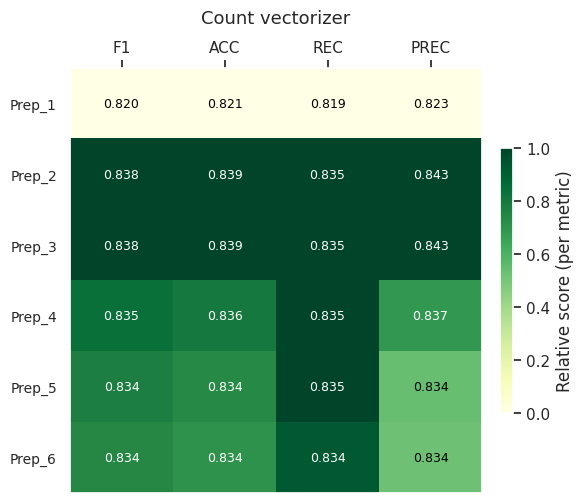

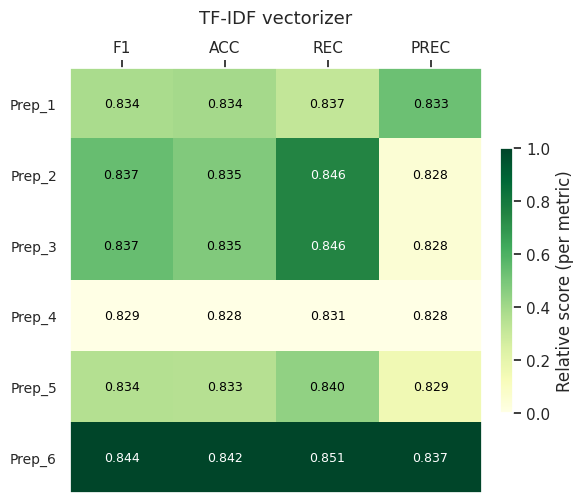

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap(df, title, filename=None):
    metrics = ["mean_f1", "mean_acc", "mean_rec","mean_prec"]
    metric_labels = ["F1", "ACC", "REC", "PREC"]
    prep_names = df["preprocessor"].tolist()
    
    # --- RAW values (for annotations) ---
    raw_data = df[metrics].values.astype(float)

    # --- NORMALIZED values (for colors only, per column) ---
    col_min = raw_data.min(axis=0)
    col_max = raw_data.max(axis=0)
    norm_data = (raw_data - col_min) / (col_max - col_min + 1e-8)

    fig, ax = plt.subplots(figsize=(6, len(prep_names) * 0.7 + 1))

    # Use normalized data for heatmap colors
    im = ax.imshow(norm_data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

    # Axes labels
    ax.grid(False)
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_yticks(range(len(prep_names)))
    ax.set_yticklabels([f"Prep_{i+1}" for i in range(len(prep_names))], fontsize=10)

    # Annotate each cell with TRUE values
    std_cols = ["std_f1", "std_acc", "std_rec", "std_prec"]
    for i in range(len(prep_names)):
        for j, (metric, std_col) in enumerate(zip(metrics, std_cols)):
            mean_val = raw_data[i, j]  
            std_val  = df.iloc[i][std_col]

            text = f"{mean_val:.3f}"

            # Use normalized value for background color
            norm_val = norm_data[i, j]
            bg_color = im.cmap(im.norm(norm_val))
            brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
            txt_color = "black" if brightness > 0.5 else "white"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
                 label="Relative score (per metric)")
    
    ax.set_title(title, fontsize=13, pad=12)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

plot_heatmap(df_count, "Count vectorizer", "images/pretest/movies_count_heatmap_prep.pdf")
plot_heatmap(df_tfidf, "TF-IDF vectorizer", "images/pretest/movies_tfidf_heatmap_prep.pdf")

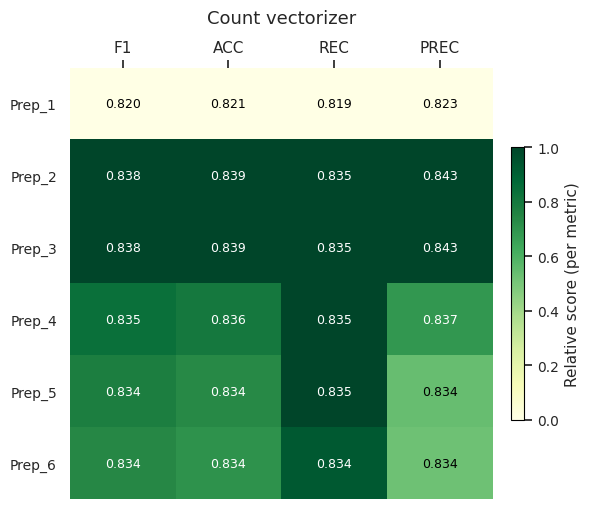

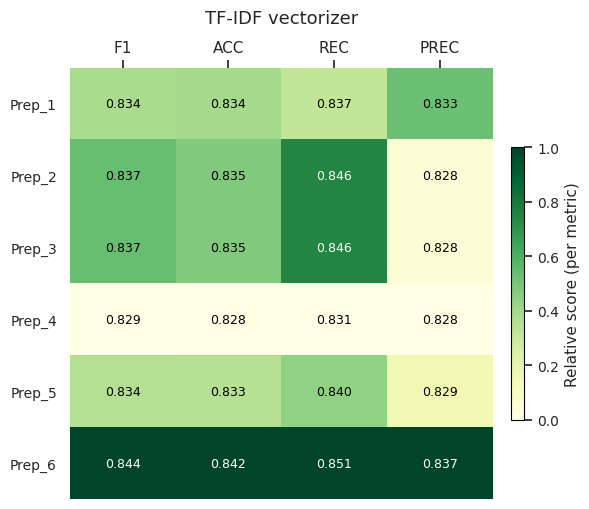

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="darkgrid")  # or "whitegrid" if you prefer
plt.rcParams.update({
    # fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "regular",
    "axes.labelweight": "regular",
    "axes.titlepad": 12,
    # tick labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 10,
    # tick / spine / grid
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "axes.grid.axis": "both",
    "grid.alpha": 0.8,
    # line / patch
    "lines.linewidth": 1.0,
    "patch.linewidth": 0.5,
    "axes.linewidth": 0.8,  # thin black borders
    "axes.edgecolor": "black",
})


#sns.set_theme(style="darkgrid")
#palette = sns.color_palette("tab10")

def plot_heatmap(df, title, filename=None):
    metrics = ["mean_f1", "mean_acc", "mean_rec","mean_prec"]
    metric_labels = ["F1", "ACC", "REC", "PREC"]
    prep_names = df["preprocessor"].tolist()
    
    # --- RAW values (for annotations) ---
    raw_data = df[metrics].values.astype(float)

    # --- NORMALIZED values (for colors only, per column) ---
    col_min = raw_data.min(axis=0)
    col_max = raw_data.max(axis=0)
    norm_data = (raw_data - col_min) / (col_max - col_min + 1e-8)

    fig, ax = plt.subplots(figsize=(6, len(prep_names) * 0.7 + 1))

    # Use normalized data for heatmap colors
    im = ax.imshow(norm_data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)

    # Axes labels
    ax.grid(False)
    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_yticks(range(len(prep_names)))
    ax.set_yticklabels([f"Prep_{i+1}" for i in range(len(prep_names))], fontsize=10)

    # Annotate each cell with TRUE values
    std_cols = ["std_f1", "std_acc", "std_rec", "std_prec"]
    for i in range(len(prep_names)):
        for j, (metric, std_col) in enumerate(zip(metrics, std_cols)):
            mean_val = raw_data[i, j]  
            std_val  = df.iloc[i][std_col]

            text = f"{mean_val:.3f}"

            # Use normalized value for background color
            norm_val = norm_data[i, j]
            bg_color = im.cmap(im.norm(norm_val))
            brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
            txt_color = "black" if brightness > 0.5 else "white"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
                 label="Relative score (per metric)")
    
    ax.set_title(title, fontsize=13, pad=12)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

plot_heatmap(df_count, "Count vectorizer", "images/pretest/movies_count_heatmap_prep.pdf")
plot_heatmap(df_tfidf, "TF-IDF vectorizer", "images/pretest/movies_tfidf_heatmap_prep.pdf")

### 4. Test with n-grams with little preprocessing and preprocessing

In [54]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english",
                punct = string.punctuation + '\n\r\t', # punctuation can contain -, that would be kept
                urls = False 
                )

In [7]:
# this time with cv on the train 
import time
import gc
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold

In [10]:
# max featu 5000 ...
# with cross validation

ranges_ngram = [(1,1), (1,2), (2,2), (1,3), (2,3), (3,3)]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for t in ranges_ngram:
    f1s, accs, recs, pres = [], [], [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        vectoriser = build_vectorizer(
            name="count",
            stop_words=final_stopwords_list,
            max_features=5000,
            ngram_range=t,
            preprocessor=prep
        )

        X_tr_vec  = vectoriser.fit_transform(X_tr)
        X_val_vec = vectoriser.transform(X_val)

        model = LogisticRegression(solver="lbfgs", max_iter=2000)
        model.fit(X_tr_vec, y_tr)

        y_val_score = model.decision_function(X_val_vec)
        y_val_pred  = model.predict(X_val_vec)

        f1s.append(f1_score(y_val, y_val_pred))
        accs.append(accuracy_score(y_val, y_val_pred))
        recs.append(recall_score(y_val, y_val_pred))
        pres.append(precision_score(y_val, y_val_pred))

        del vectoriser, model, X_tr_vec, X_val_vec
        gc.collect()

    results.append({
        "ngram_range": t,
        "mean_f1":  np.mean(f1s),  "std_f1":  np.std(f1s),
        "mean_acc":  np.mean(accs),  "std_acc":  np.std(accs),
        "mean_rec":  np.mean(recs),  "std_rec":  np.std(recs),
        "mean_pre":  np.mean(pres),  "std_pre":  np.std(pres),
    })

    print(f"n-gram range: {t}")
    print(f"  F1 : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"  Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"  Recall : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"  Precision : {np.mean(pres):.4f} ± {np.std(pres):.4f}")


n-gram range: (1, 1)
  F1 : 0.8380 ± 0.0175
  Accuracy : 0.8381 ± 0.0169
  Recall : 0.8385 ± 0.0207
  Precision : 0.8374 ± 0.0147
n-gram range: (1, 2)
  F1 : 0.8428 ± 0.0180
  Accuracy : 0.8438 ± 0.0163
  Recall : 0.8398 ± 0.0270
  Precision : 0.8461 ± 0.0121
n-gram range: (2, 2)
  F1 : 0.7419 ± 0.0194
  Accuracy : 0.7450 ± 0.0170
  Recall : 0.7347 ± 0.0309
  Precision : 0.7501 ± 0.0194
n-gram range: (1, 3)
  F1 : 0.8400 ± 0.0172
  Accuracy : 0.8406 ± 0.0156
  Recall : 0.8386 ± 0.0257
  Precision : 0.8416 ± 0.0100
n-gram range: (2, 3)
  F1 : 0.7358 ± 0.0123
  Accuracy : 0.7406 ± 0.0079
  Recall : 0.7247 ± 0.0384
  Precision : 0.7495 ± 0.0203
n-gram range: (3, 3)
  F1 : 0.5722 ± 0.0313
  Accuracy : 0.6025 ± 0.0246
  Recall : 0.5332 ± 0.0363
  Precision : 0.6178 ± 0.0263


In [11]:
import pandas as pd
import seaborn as sns

df_ngram = pd.DataFrame(results)
print(df_ngram.to_string(index=False))

ngram_range  mean_f1   std_f1  mean_acc  std_acc  mean_rec  std_rec  mean_pre  std_pre
     (1, 1) 0.837958 0.017504  0.838125 0.016933  0.838546 0.020708  0.837407 0.014673
     (1, 2) 0.842787 0.017984  0.843750 0.016298  0.839796 0.027006  0.846081 0.012135
     (2, 2) 0.741901 0.019445  0.745000 0.016956  0.734717 0.030916  0.750055 0.019433
     (1, 3) 0.839959 0.017245  0.840625 0.015562  0.838553 0.025704  0.841578 0.010031
     (2, 3) 0.735842 0.012300  0.740625 0.007906  0.724748 0.038447  0.749463 0.020292
     (3, 3) 0.572212 0.031308  0.602500 0.024638  0.533208 0.036281  0.617822 0.026301


In [ ]:
print(df_ngram.columns)
print(df_ngram[['mean_pre', 'std_pre']])
#print(means['PREC'])
#print(stds['PREC'])


Index(['ngram_range', 'mean_f1', 'std_f1', 'mean_acc', 'std_acc', 'mean_rec',
       'std_rec', 'mean_pre', 'std_pre'],
      dtype='str')
   mean_pre   std_pre
0  0.837407  0.014673
1  0.846081  0.012135
2  0.750055  0.019433
3  0.841578  0.010031
4  0.749463  0.020292
5  0.617822  0.026301
[0.8374074931512135, 0.8460813871174742, 0.7500550577383971, 0.8415778029191572, 0.7494631837100021, 0.6178223740028737]
[0.014673371696228791, 0.012134983231915995, 0.019433229226198948, 0.010031313594497462, 0.020291634798945708, 0.02630115467624297]


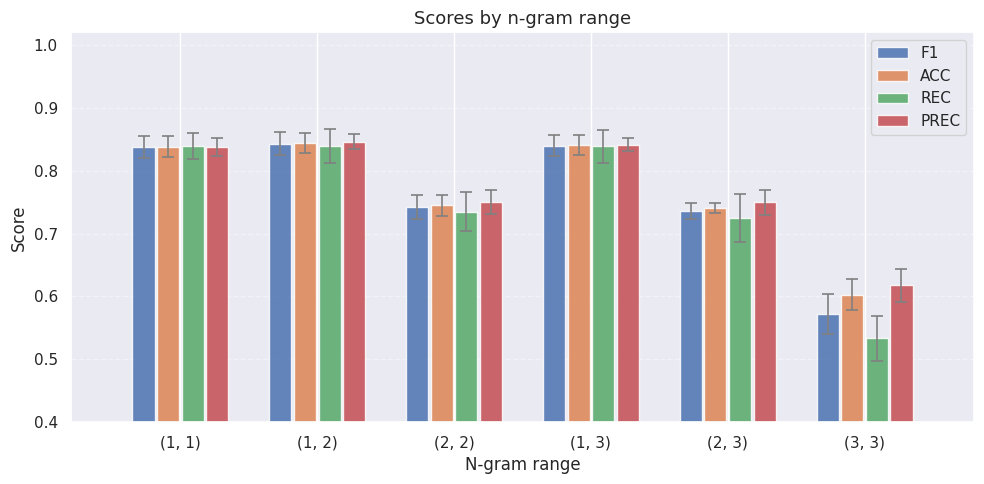

'\n\n\nn_metrics = len(means)\nwidth = 0.25\noffsets = np.linspace(-1.5*width, 1.5*width, n_metrics)  # for 4 metrics\n\nfor (metric, color), offset in zip([(m, colors[m]) for m in means], offsets):\n    ax.bar(x + offset, means[metric], width=0.9*width,\n           yerr=stds[metric], capsize=4,\n           label=metric, color=color, alpha=0.85,\n           error_kw=dict(elinewidth=1.2, ecolor=\'gray\', capthick=1.2))\n\nax.set_xticks(x)\nax.set_xticklabels(labels)\nax.set_xlabel(\'N-gram range\', fontsize=12)\nax.set_ylabel(\'Score\', fontsize=12)\nax.set_title(\'Scores by n-gram range\', fontsize=13, fontweight=\'medium\')\nax.set_ylim(0.4, 1.02)\nax.set_xlim(-0.8, len(labels) + 0.010)\nax.legend(loc="upper right")\nax.yaxis.grid(True, linestyle=\'--\', alpha=0.4)\nax.set_axisbelow(True)\n\nplt.tight_layout()\nplt.savefig(\'images/pretest/movies_ngram_metrics.pdf\')\nplt.show()\n'

In [28]:
means = {
    'F1':  df_ngram['mean_f1'].tolist(),
    'ACC':  df_ngram['mean_acc'].tolist(),
    'REC': df_ngram['mean_rec'].tolist(),
    'PREC': df_ngram['mean_pre'].tolist(),
}
stds = {
    'F1':  df_ngram['std_f1'].tolist(),
    'ACC':  df_ngram['std_acc'].tolist(),
    'REC': df_ngram['std_rec'].tolist(),
    'PREC': df_ngram['std_pre'].tolist(),
}

sns.set_theme(style="darkgrid")
palette = sns.color_palette("tab10",4)

labels = df_ngram['ngram_range'].astype(str).tolist()

colors = {'F1': sns.color_palette()[0], 'ACC': sns.color_palette()[1], 'REC': sns.color_palette()[2], 'PREC': sns.color_palette()[3]}

#fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="darkgrid")
"""
x = np.arange(len(labels))
n_metrics = len(means)
width = 0.25
offsets = [-width, 0, width]
for (metric, color), offset in zip([(m, colors[m]) for m in means], offsets):
    bars = ax.bar(x + offset, means[metric], width=width - 0.02,
                  yerr=stds[metric], capsize=4,
                  label=metric, color=color, alpha=0.85,
                  error_kw=dict(elinewidth=1.2, ecolor='gray', capthick=1.2))
"""
n_metrics = len(means)
width = 0.18  # smaller width → more space between groups
n_groups = len(labels)
group_spacing = 1.0  # desired distance between centers of groups
x = np.arange(0, n_groups * group_spacing, group_spacing)  # spaced group centers

offsets = np.linspace(-0.5*width*(n_metrics-1), 0.5*width*(n_metrics-1), n_metrics)

fig, ax = plt.subplots(figsize=(10, 5))

for (metric, color), offset in zip([(m, colors[m]) for m in means], offsets):
    ax.bar(x + offset, means[metric], width=0.9*width,
           yerr=stds[metric], capsize=4,
           label=metric, color=color, alpha=0.85,
           error_kw=dict(elinewidth=1.2, ecolor='gray', capthick=1.2))

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('N-gram range', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Scores by n-gram range', fontsize=13, fontweight='medium')
ax.set_ylim(0.4, 1.02)
ax.set_xlim(-0.8, x[-1] + 0.8)  # more space at the edges
ax.legend(loc="upper right")
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('images/pretest/movies_ngram_metrics.pdf')
plt.show()
"""


n_metrics = len(means)
width = 0.25
offsets = np.linspace(-1.5*width, 1.5*width, n_metrics)  # for 4 metrics

for (metric, color), offset in zip([(m, colors[m]) for m in means], offsets):
    ax.bar(x + offset, means[metric], width=0.9*width,
           yerr=stds[metric], capsize=4,
           label=metric, color=color, alpha=0.85,
           error_kw=dict(elinewidth=1.2, ecolor='gray', capthick=1.2))

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('N-gram range', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Scores by n-gram range', fontsize=13, fontweight='medium')
ax.set_ylim(0.4, 1.02)
ax.set_xlim(-0.8, len(labels) + 0.010)
ax.legend(loc="upper right")
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('images/pretest/movies_ngram_metrics.pdf')
plt.show()
"""

### 5. Vector size 
- word2vec,fastext, doc2vec on trained data, different size

In [50]:
def stopwords_rmv(text, stopwords=final_stopwords_list):
    return " ".join([word for word in text.split() if word not in stopwords])


In [31]:
# import the 3 models, run them
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# ── helpers ──────────────────────────────────────────────────────────────────

def mean_embed_wv(texts, model):
    """Word2Vec / FastText: mean pool over known words."""
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def embed_doc2vec(texts, model):
    """Doc2Vec: infer one vector per document."""
    return np.array([model.infer_vector(t.split()) for t in texts])

def run_cv(X, y, n_splits=5):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
    ])
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1", "accuracy",
                                     "recall", "precision",])
    return {
        "F1":            scores["test_f1"].mean(),
        "F1_std":        scores["test_f1"].std(),
        "ACC":           scores["test_accuracy"].mean(),
        "ACC_std":       scores["test_accuracy"].std(),
        "Precision":     scores["test_precision"].mean(),
        "Precision_std": scores["test_precision"].std(),
        "Recall":        scores["test_recall"].mean(),
        "Recall_std":    scores["test_recall"].std(),
    }

# ── preprocessing (reuse your existing prep + stopword removal) ───────────────

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]   # full dataset
all_texts_tok = [t.split() for t in all_texts]                   # tokenized

# ── experiment loop ───────────────────────────────────────────────────────────

SIZES   = [100, 200, 300]
RESULTS = []

for size in SIZES:
    print(f"\n{'='*40}\nVector size: {size}\n{'='*40}")

    # ── Word2Vec (skip-gram) ──────────────────────────────────────────────────
    w2v = Word2Vec(sentences=all_texts_tok, vector_size=size, window=5,
                   min_count=5, sg=1, epochs=5, workers=3)
    X_w2v = mean_embed_wv(all_texts, w2v)
    m = run_cv(X_w2v, y_train)
    RESULTS.append({"model": "Word2Vec", "size": size, **m})
    print(f"Word2Vec  {size}d : F1={m['F1']:.4f}  ACC={m['ACC']:.4f}  Prec={m['Precision']:.4f}  Rec={m['Recall']:.4f}")

    # ── FastText (skip-gram) ──────────────────────────────────────────────────
    ft = FastText(sentences=all_texts_tok, vector_size=size, window=5,
                  min_count=1, sg=1, epochs=5, workers=3)
    X_ft = mean_embed_wv(all_texts, ft)
    m = run_cv(X_ft, y_train)
    RESULTS.append({"model": "FastText", "size": size, **m})
    print(f"FastText  {size}d : F1={m['F1']:.4f}  ACC={m['ACC']:.4f}  Prec={m['Precision']:.4f}  Rec={m['Recall']:.4f}")

    # ── Doc2Vec (PV-DBOW, skip-gram equivalent) ───────────────────────────────
    tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
    d2v = Doc2Vec(tagged, vector_size=size, window=5,
                  min_count=1, dm=0, epochs=20, workers=4)
    X_d2v = embed_doc2vec(all_texts, d2v)
    m = run_cv(X_d2v, y_train)
    RESULTS.append({"model": "Doc2Vec", "size": size, **m})
    print(f"Doc2Vec   {size}d : F1={m['F1']:.4f}  ACC={m['ACC']:.4f}  Prec={m['Precision']:.4f}  Rec={m['Recall']:.4f}")

# ── collect ───────────────────────────────────────────────────────────────────

df_results = pd.DataFrame(RESULTS)
print("\n", df_results.to_string(index=False))



Vector size: 100
Word2Vec  100d : F1=0.7850  ACC=0.7812  Prec=0.7725  Rec=0.7985
FastText  100d : F1=0.7845  ACC=0.7837  Prec=0.7820  Rec=0.7873
Doc2Vec   100d : F1=0.8340  ACC=0.8350  Prec=0.8378  Rec=0.8310

Vector size: 200
Word2Vec  200d : F1=0.8013  ACC=0.8019  Prec=0.8030  Rec=0.7998
FastText  200d : F1=0.7746  ACC=0.7725  Prec=0.7662  Rec=0.7835
Doc2Vec   200d : F1=0.8291  ACC=0.8300  Prec=0.8314  Rec=0.8273

Vector size: 300
Word2Vec  300d : F1=0.7942  ACC=0.7925  Prec=0.7877  Rec=0.8010
FastText  300d : F1=0.7881  ACC=0.7875  Prec=0.7842  Rec=0.7923
Doc2Vec   300d : F1=0.8117  ACC=0.8125  Prec=0.8120  Rec=0.8122

    model  size       F1   F1_std      ACC  ACC_std  Precision  Precision_std   Recall  Recall_std
Word2Vec   100 0.784970 0.016937 0.781250 0.020444   0.772471       0.028001 0.798491    0.014568
FastText   100 0.784498 0.019113 0.783750 0.021506   0.781996       0.026999 0.787264    0.013840
 Doc2Vec   100 0.834010 0.022450 0.835000 0.021139   0.837779       0.0243

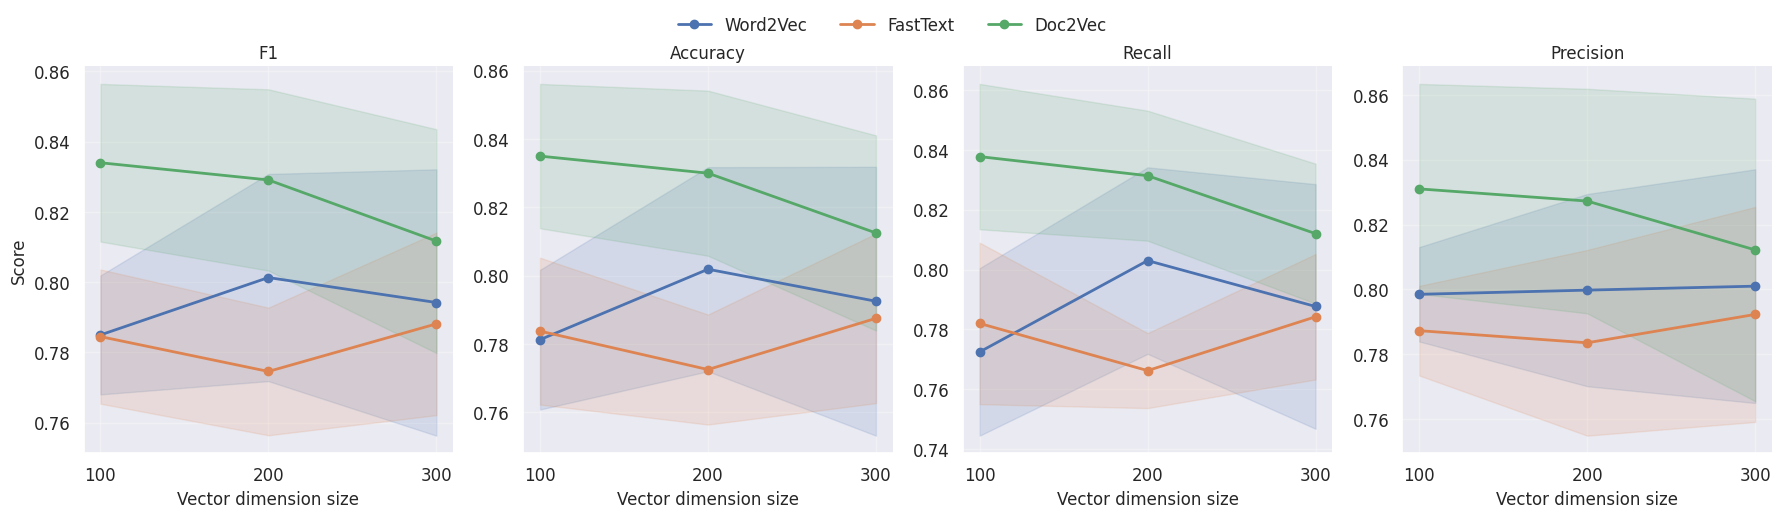

In [34]:
import matplotlib.pyplot as plt

METRICS = ["F1", "ACC",  "Precision", "Recall"]
LABELS  = ["F1",  "Accuracy",  "Recall", "Precision"]
MODELS  = ["Word2Vec", "FastText", "Doc2Vec"]
COLORS  = {"Word2Vec": sns.color_palette()[0], "FastText": sns.color_palette()[1], "Doc2Vec":sns.color_palette()[2]}
SIZES   = [100, 200, 300]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, label in zip(axes, METRICS, LABELS):
    for model in MODELS:
        subset = df_results[df_results["model"] == model].sort_values("size")
        ax.plot(subset["size"], subset[metric], marker="o",
                color=COLORS[model], linewidth=2, label=model)
        ax.fill_between(subset["size"],
                        subset[metric] - subset[f"{metric}_std"],
                        subset[metric] + subset[f"{metric}_std"],
                        color=COLORS[model], alpha=0.15)
    ax.set_title(label, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Vector dimension size", fontsize=12)
    ax.set_xticks(SIZES)
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=12)


axes[0].set_ylabel("Score", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=12)

# # colored text labels on the right, outside the last subplot
# for i, model in enumerate(MODELS):
#     fig.text(1.01, 0.75 - i * 0.15, model,
#              color=COLORS[model],
#              fontsize=10, fontweight="500",
#              va="center", transform=axes[-1].transAxes)

plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.savefig("images/pretest/movies_vectors_size_metrics.pdf", dpi=150, bbox_inches="tight")
plt.show()

### 5. Test of different embeddings

In [66]:
RESULTS = []  # accumulate across all cells

def run_cv(X, y, n_splits=5, scaling = True):
    """Scale + LR inside a pipeline, return mean CV metrics."""
    if scaling :
        pipe = Pipeline([
            # ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
        ])
    else:
        pipe = Pipeline([
            ("clf",    LogisticRegression(solver="lbfgs", max_iter=2000))
        ])
    
    scores = cross_validate(pipe, X, y, cv=n_splits,
                            scoring=["f1", "accuracy",
                                     "recall", "precision",])
    return {
        "F1":            scores["test_f1"].mean(),
        "F1_std":        scores["test_f1"].std(),
        "ACC":           scores["test_accuracy"].mean(),
        "ACC_std":       scores["test_accuracy"].std(),
        "PREC":     scores["test_precision"].mean(),
        "PREC_std": scores["test_precision"].std(),
        "REC":        scores["test_recall"].mean(),
        "REC_std":    scores["test_recall"].std(),
    }


def mean_embed_wv(texts, model): # sitck mean
    vecs = []
    for text in texts:
        words = text.split()
        ws = [model.wv[w] for w in words if w in model.wv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(model.vector_size))
    return np.array(vecs)

def log_result(name, metrics):
    RESULTS.append({"model": name, **metrics})
    print(f"{name:40s} : F1={metrics['F1']:.4f}  ACC={metrics['Accuracy']:.4f} Prec={metrics['Precision']:.4f}  Rec={metrics['Recall']:.4f}")

all_texts = [stopwords_rmv(prep.process(t)) for t in X_train]
all_texts_tok = [t.split() for t in all_texts]

BEST_SIZE = 200 

#### Count + tfidf

In [52]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.model_selection import train_test_split, cross_validate

# no StandardScaler here — sparse matrices, TF-IDF already normalized
def run_cv_sparse(X, y, n_splits=5):
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    
    scores = cross_validate(clf, X, y, cv=n_splits,
                            scoring=["f1", "accuracy",
                                     "recall", "precision",])
    return {
        "F1":            scores["test_f1"].mean(),
        "F1_std":        scores["test_f1"].std(),
        "ACC":           scores["test_accuracy"].mean(),
        "ACC_std":       scores["test_accuracy"].std(),
        "PREC":     scores["test_precision"].mean(),
        "PREC_std": scores["test_precision"].std(),
        "REC":        scores["test_recall"].mean(),
        "REC_std":    scores["test_recall"].std(),
    }


cv_vec   = CountVectorizer()
tfidf_vec = TfidfVectorizer()

X_cv    = cv_vec.fit_transform(all_texts)
X_tfidf = tfidf_vec.fit_transform(all_texts)

log_result("CountVectorizer",  run_cv_sparse(X_cv,    y_train))
log_result("TF-IDF",           run_cv_sparse(X_tfidf, y_train))

CountVectorizer                          : F1=0.8387  ACC=0.8406 Prec=0.8475  Rec=0.8311
TF-IDF                                   : F1=0.8278  ACC=0.8262 Prec=0.8199  Rec=0.8361


#### Word2V, Fastext, D2V

In [53]:
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.pipeline import Pipeline

# Word2Vec
w2v = Word2Vec(sentences=all_texts_tok, vector_size=BEST_SIZE,
               window=5, min_count=5, sg=1, epochs=5, workers=3)
log_result(f"Word2Vec (trained {BEST_SIZE}d)", run_cv(mean_embed_wv(all_texts, w2v), y_train))

# FastText
ft = FastText(sentences=all_texts_tok, vector_size=BEST_SIZE,
              window=5, min_count=1, sg=1, epochs=5, workers=3)
log_result(f"FastText (trained {BEST_SIZE}d)", run_cv(mean_embed_wv(all_texts, ft), y_train))

# Doc2Vec
tagged = [TaggedDocument(t.split(), [i]) for i, t in enumerate(all_texts)]
d2v = Doc2Vec(tagged, vector_size=BEST_SIZE, window=5,
              min_count=1, dm=0, epochs=20, workers=4)

X_d2v = np.array([d2v.infer_vector(t.split()) for t in all_texts])
log_result(f"Doc2Vec (trained {BEST_SIZE}d)", run_cv(X_d2v, y_train))

Word2Vec (trained 200d)                  : F1=0.7125  ACC=0.7156 Prec=0.7193  Rec=0.7084
FastText (trained 200d)                  : F1=0.6760  ACC=0.6769 Prec=0.6761  Rec=0.6771
Doc2Vec (trained 200d)                   : F1=0.8311  ACC=0.8325 Prec=0.8394  Rec=0.8248


#### W2V, Fastext pretrained (ppti)

In [ ]:
#import fasttext.util
#fasttext.util.download_model('en', if_exists='ignore')
"""
ft_bin = fasttext.load_model("cc.en.300.bin")
# build a KeyedVectors‑style wrapper
words = ft_bin.get_words()
dim = ft_bin.get_dimension()
kv_vec = KeyedVectors(vector_size=dim)
kv_vec.add_vectors(words, [ft_bin.get_word_vector(w) for w in words])
"""


In [64]:
"""
from gensim.models import KeyedVectors
from gensim.models.fasttext import load_facebook_model

# cc.fr.300.vec — behaves like Word2Vec, no subword info
kv_vec = KeyedVectors.load_word2vec_format("cc.fr.300.vec", binary=False)
log_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_wv(all_texts, type('M', (), {'wv': kv_vec, 'vector_size': 300})()), y_train))

# cleaner helper that works directly with KeyedVectors
def mean_embed_kv(texts, kv):
    vecs = []
    for text in texts:
        words = text.split()
        ws = [kv[w] for w in words if w in kv]
        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(kv.vector_size))
    return np.array(vecs)

log_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_kv(all_texts, kv_vec), y_train))

ft_bin = load_facebook_model("cc.fr.300.bin")
log_result("cc.fr.300.bin (FastText)",  run_cv(mean_embed_wv(all_texts, ft_bin), y_train))
"""

'\nfrom gensim.models import KeyedVectors\nfrom gensim.models.fasttext import load_facebook_model\n\n# cc.fr.300.vec — behaves like Word2Vec, no subword info\nkv_vec = KeyedVectors.load_word2vec_format("cc.fr.300.vec", binary=False)\nlog_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_wv(all_texts, type(\'M\', (), {\'wv\': kv_vec, \'vector_size\': 300})()), y_train))\n\n# cleaner helper that works directly with KeyedVectors\ndef mean_embed_kv(texts, kv):\n    vecs = []\n    for text in texts:\n        words = text.split()\n        ws = [kv[w] for w in words if w in kv]\n        vecs.append(np.mean(ws, axis=0) if ws else np.zeros(kv.vector_size))\n    return np.array(vecs)\n\nlog_result("cc.fr.300.vec (W2V-like)", run_cv(mean_embed_kv(all_texts, kv_vec), y_train))\n\nft_bin = load_facebook_model("cc.fr.300.bin")\nlog_result("cc.fr.300.bin (FastText)",  run_cv(mean_embed_wv(all_texts, ft_bin), y_train))\n'

In [62]:
# load the results
import json 
with open("results_json/movies_w2v_fasttext__results.json") as json_file:
    json_data_w2v_ft = json.load(json_file)

In [67]:
log_result("Word2Vec", json_data_w2v_ft[0])
log_result("FastText", json_data_w2v_ft[1])

Word2Vec                                 : F1=0.7880  ACC=0.7881 Prec=0.7886  Rec=0.7881
FastText                                 : F1=0.7930  ACC=0.7931 Prec=0.7937  Rec=0.7931


In [68]:
# tmp sav
RESULTS

[{'model': 'cc.en.300.vec (W2V-like)',
  'F1': 0.7880437222539316,
  'F1_std': 0.027225528622588924,
  'AUC': 0.8647890625000001,
  'AUC_std': 0.020133565844946886,
  'AvgPrec': 0.8581488254748167,
  'AvgPrec_std': 0.016169115093687614,
  'Precision': 0.7886351342042243,
  'Precision_std': 0.027608755408105787,
  'Recall': 0.7881250000000001,
  'Recall_std': 0.027271780286589276,
  'Accuracy': 0.7881250000000001,
  'Accuracy_std': 0.027271780286589276},
 {'model': 'cc.en.300.bin (FastText)',
  'F1': 0.7930333322649995,
  'F1_std': 0.02013973225643834,
  'AUC': 0.8635468749999999,
  'AUC_std': 0.018398419254237235,
  'AvgPrec': 0.8551802678955879,
  'AvgPrec_std': 0.014831727811686988,
  'Precision': 0.7937040199206844,
  'Precision_std': 0.020573204222459666,
  'Recall': 0.7931250000000001,
  'Recall_std': 0.020194368026754398,
  'Accuracy': 0.7931250000000001,
  'Accuracy_std': 0.020194368026754412}]

#### Transformers

In [55]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "intfloat/multilingual-e5-base", 
)
model.save("./model_emb_e5")

/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3957.00it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


In [57]:
from sentence_transformers import SentenceTransformer
model_name = "intfloat/multilingual-e5-base"
# texts WITHOUT stopword removal for transformers
raw_texts = [prep.process(t) for t in X_train]  # light prep, keep stopwords
x
st_model = SentenceTransformer("./model_emb_e5", device = "cpu")

X_st = st_model.encode(raw_texts, batch_size=8, show_progress_bar=True)
log_result(f"Transformer ({model_name.split('/')[-1]})", run_cv(X_st, y_train))

Batches: 100%|██████████| 200/200 [23:12<00:00,  6.96s/it]


Transformer (multilingual-e5-base)       : F1=0.7893  ACC=0.7850 Prec=0.7748  Rec=0.8060


In [70]:
log_result(f"Transformer (embed)", run_cv(X_st, y_train))

KeyError: 'Accuracy'

In [59]:
RESULTS 

[{'model': 'CountVectorizer',
  'F1': np.float64(0.8387088725558055),
  'F1_std': np.float64(0.009320091989863473),
  'ACC': np.float64(0.840625),
  'ACC_std': np.float64(0.0055901699437494665),
  'PREC': np.float64(0.8474956866804693),
  'PREC_std': np.float64(0.012247228951554294),
  'REC': np.float64(0.8310770440251571),
  'REC_std': np.float64(0.02859081857256386)},
 {'model': 'TF-IDF',
  'F1': np.float64(0.8278146923118644),
  'F1_std': np.float64(0.01572232706128872),
  'ACC': np.float64(0.8262499999999999),
  'ACC_std': np.float64(0.016488632447841135),
  'PREC': np.float64(0.8199372070150682),
  'PREC_std': np.float64(0.020723295941220462),
  'REC': np.float64(0.836061320754717),
  'REC_std': np.float64(0.015348573881149975)},
 {'model': 'Word2Vec (trained 200d)',
  'F1': np.float64(0.7124823527362529),
  'F1_std': np.float64(0.036668217327074114),
  'ACC': np.float64(0.7156250000000001),
  'ACC_std': np.float64(0.03241575619972485),
  'PREC': np.float64(0.7193372896058483),
  

In [72]:
# results from our previous calls, we set it here to not have to re run 
RESULTS = [{'model': 'CountVectorizer',
  'F1': np.float64(0.8387088725558055),
  'F1_std': np.float64(0.009320091989863473),
  'ACC': np.float64(0.840625),
  'ACC_std': np.float64(0.0055901699437494665),
  'PREC': np.float64(0.8474956866804693),
  'PREC_std': np.float64(0.012247228951554294),
  'REC': np.float64(0.8310770440251571),
  'REC_std': np.float64(0.02859081857256386)},
 {'model': 'TF-IDF',
  'F1': np.float64(0.8278146923118644),
  'F1_std': np.float64(0.01572232706128872),
  'ACC': np.float64(0.8262499999999999),
  'ACC_std': np.float64(0.016488632447841135),
  'PREC': np.float64(0.8199372070150682),
  'PREC_std': np.float64(0.020723295941220462),
  'REC': np.float64(0.836061320754717),
  'REC_std': np.float64(0.015348573881149975)},
 {'model': 'Word2Vec (trained 200d)',
  'F1': np.float64(0.7124823527362529),
  'F1_std': np.float64(0.036668217327074114),
  'ACC': np.float64(0.7156250000000001),
  'ACC_std': np.float64(0.03241575619972485),
  'PREC': np.float64(0.7193372896058483),
  'PREC_std': np.float64(0.032881724522184776),
  'REC': np.float64(0.7084040880503144),
  'REC_std': np.float64(0.05794813613864523)},
 {"model": "cc.en.300.vec (W2V-like)",
  "F1": 0.7880437222539316,
  "F1_std": 0.027225528622588924,
  "PREC": 0.7886351342042243,
  "PREC_std": 0.027608755408105787,
  "REC": 0.7881250000000001,
  "REC_std": 0.027271780286589276,
  "ACC": 0.7881250000000001,
  "ACC_std": 0.027271780286589276},
 {'model': 'FastText (trained 200d)',
  'F1': np.float64(0.676011396943038),
  'F1_std': np.float64(0.032352677013559636),
  'ACC': np.float64(0.676875),
  'ACC_std': np.float64(0.0271425634382606),
  'PREC': np.float64(0.6761010928496705),
  'PREC_std': np.float64(0.023276561501571365),
  'REC': np.float64(0.6771147798742139),
  'REC_std': np.float64(0.048707791205239354)},
 {"model": "cc.en.300.bin (FastText)",
  "F1": 0.7930333322649995,
  "F1_std": 0.02013973225643834,
  "PREC": 0.7937040199206844,
  "PREC_std": 0.020573204222459666,
  "REC": 0.7931250000000001,
  "REC_std": 0.020194368026754398,
  "ACC": 0.7931250000000001,
  "ACC_std": 0.020194368026754412}, 
 {'model': 'Doc2Vec (trained 200d)',
  'F1': np.float64(0.8310937690124505),
  'F1_std': np.float64(0.006829722622854958),
  'ACC': np.float64(0.8325000000000001),
  'ACC_std': np.float64(0.00980274196334882),
  'PREC': np.float64(0.8394347197583757),
  'PREC_std': np.float64(0.032092958330017324),
  'REC': np.float64(0.824819182389937),
  'REC_std': np.float64(0.02660036991102764)},
 {'model': 'Transformer (multilingual-e5-base)',
  'F1': np.float64(0.7893010750676719),
  'F1_std': np.float64(0.02653423196334741),
  'ACC': np.float64(0.7849999999999999),
  'ACC_std': np.float64(0.028048507090396115),
  'PREC': np.float64(0.7747853118495146),
  'PREC_std': np.float64(0.03793724642320422),
  'REC': np.float64(0.8059984276729558),
  'REC_std': np.float64(0.03428225209391861)},
 {'model': 'Transformer (embed)',
  'F1': np.float64(0.7893010750676719),
  'F1_std': np.float64(0.02653423196334741),
  'ACC': np.float64(0.7849999999999999),
  'ACC_std': np.float64(0.028048507090396115),
  'PREC': np.float64(0.7747853118495146),
  'PREC_std': np.float64(0.03793724642320422),
  'REC': np.float64(0.8059984276729558),
  'REC_std': np.float64(0.03428225209391861)},
 ]

                             model       F1   F1_std      ACC  ACC_std     PREC  PREC_std      REC  REC_std
                   CountVectorizer 0.838709 0.009320 0.840625 0.005590 0.847496  0.012247 0.831077 0.028591
                            TF-IDF 0.827815 0.015722 0.826250 0.016489 0.819937  0.020723 0.836061 0.015349
           Word2Vec (trained 200d) 0.712482 0.036668 0.715625 0.032416 0.719337  0.032882 0.708404 0.057948
          cc.en.300.vec (W2V-like) 0.788044 0.027226 0.788125 0.027272 0.788635  0.027609 0.788125 0.027272
           FastText (trained 200d) 0.676011 0.032353 0.676875 0.027143 0.676101  0.023277 0.677115 0.048708
          cc.en.300.bin (FastText) 0.793033 0.020140 0.793125 0.020194 0.793704  0.020573 0.793125 0.020194
            Doc2Vec (trained 200d) 0.831094 0.006830 0.832500 0.009803 0.839435  0.032093 0.824819 0.026600
Transformer (multilingual-e5-base) 0.789301 0.026534 0.785000 0.028049 0.774785  0.037937 0.805998 0.034282
               Transformer (

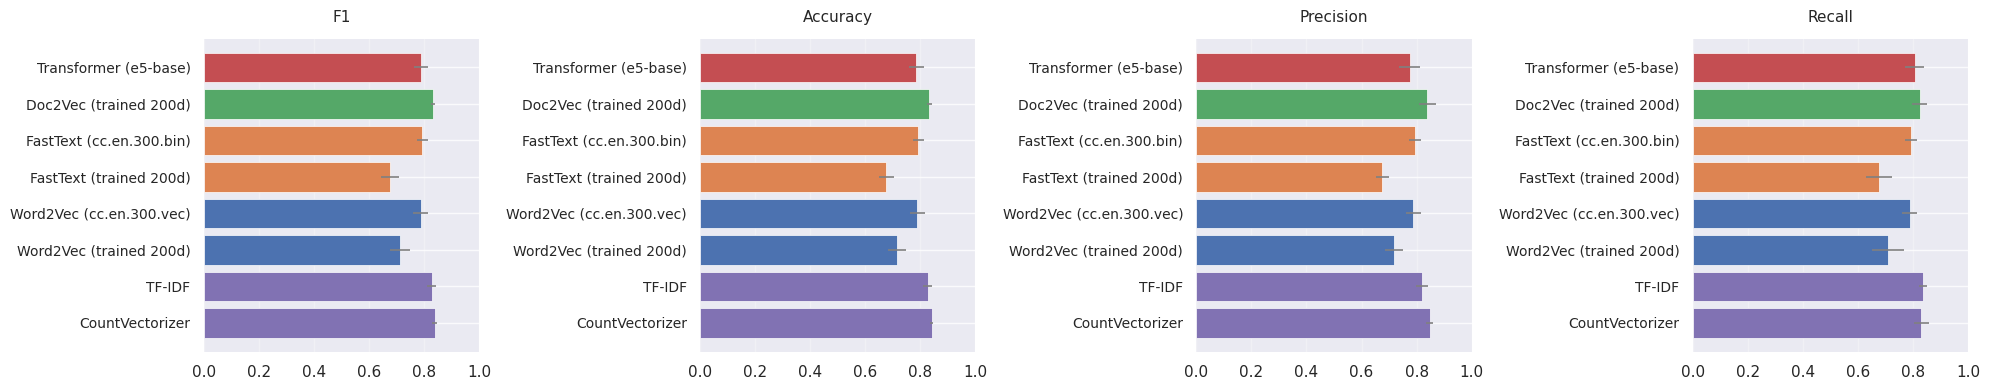

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame(RESULTS)
print(df_results.to_string(index=False))

order = [
    "CountVectorizer",
    "TF-IDF",
    "Word2Vec (trained 200d)",
    "cc.en.300.vec (W2V-like)",
    "FastText (trained 200d)",
    "cc.en.300.bin (FastText)",
    "Doc2Vec (trained 200d)",
    "Transformer (embed)",
]

df_plot = df_results.set_index("model").reindex([m for m in order if m in df_results["model"].values]).reset_index()
df_plot = df_plot.replace({
    "cc.en.300.vec (W2V-like)": "Word2Vec (cc.en.300.vec)",
    "cc.en.300.bin (FastText)": "FastText (cc.en.300.bin)",
    "Transformer (embed)": "Transformer (e5-base)",})

# same plotting code as before, adapted for model names on x axis

METRICS = ["F1", "ACC", "PREC", "REC"]    #  "Precision", "Recall"
LABELS  = ["F1", "Accuracy", "Precision", "Recall"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric, label in zip(axes, METRICS, LABELS):
    vals = df_plot[metric]
    colors = [sns.color_palette()[0] if "Word2Vec" in m 
              else sns.color_palette()[1] if "Fast" in m
              else sns.color_palette()[2] if "Doc" in m
              else sns.color_palette()[3] if "Transformer" in m
              else sns.color_palette()[4]
              for m in df_plot["model"]]
    ax.barh(df_plot["model"], vals, color=colors, xerr=df_plot[f"{metric}_std"], error_kw={"elinewidth": 1.2, "ecolor": "gray"})
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 1)
    # ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("images/pretest/movies_vectorizer_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()

### 6. POS Tag RNN (ran PPTI)

python file pos_tag_rnn.py

## Re baseline

class majoritary

In [ ]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score    

f1_train, f1_test = f1_score(y_train, np.ones(len(y_train)), average='macro'), f1_score(y_test, np.ones(len(y_test)), average='macro')
ap_train, ap_test = average_precision_score(y_train, np.ones(len(y_train))), average_precision_score(y_test, np.ones(len(y_test)))
auc_train, auc_test = roc_auc_score(y_train, np.ones(len(y_train))), roc_auc_score(y_test, np.ones(len(y_test)))
prec_train, prec_test = precision_score(y_train, np.ones(len(y_train))), precision_score(y_test, np.ones(len(y_test)), average='macro')
rec_train, rec_test = recall_score(y_train, np.ones(len(y_train))), recall_score(y_test, np.ones(len(y_test)), average='macro')

print(auc_train, auc_test)
print(f1_train, f1_test)
print(ap_train, ap_test)
print(rec_train, rec_test)
print(prec_train, prec_test)

0.5 0.5
0.4649472286293423 0.46493639625366945
0.8689745264532985 0.8689366890185491
1.0 0.5
0.8689745264532985 0.4344683445092746


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


random predictions, over 30 runs 

In [ ]:
np.random.seed(0)
n_runs = 30

f1_train_scores, f1_test_scores = [], []
ap_train_scores, ap_test_scores = [], []
auc_train_scores, auc_test_scores = [], []
prec_train_scores, prec_test_scores = [], []
rec_train_scores, rec_test_scores = [], []

for _ in range(n_runs):
    a = np.random.choice([-1, 1], size=len(y_train))
    b = np.random.choice([-1, 1], size=len(y_test))

    f1_train_scores.append(f1_score(y_train, a, average="macro"))
    f1_test_scores.append(f1_score(y_test, b, average="macro"))

    ap_train_scores.append(average_precision_score(y_train, a))
    ap_test_scores.append(average_precision_score(y_test, b))

    auc_train_scores.append(roc_auc_score(y_train, np.where(a == 1, 1, 0)))
    auc_test_scores.append(roc_auc_score(y_test, np.where(b == 1, 1, 0)))

    prec_train_scores.append(precision_score(y_train, a, average='macro'))
    prec_test_scores.append(precision_score(y_test, b, average='macro'))

    rec_train_scores.append(recall_score(y_train, a, average='macro'))
    rec_test_scores.append(recall_score(y_test, b, average='macro'))

print("Mean over 30 random runs:")
print("AUC:", np.mean(auc_train_scores), np.mean(auc_test_scores))
print("F1:", np.mean(f1_train_scores), np.mean(f1_test_scores))
print("AP:", np.mean(ap_train_scores), np.mean(ap_test_scores))
print("Recall:", np.mean(rec_train_scores), np.mean(rec_test_scores))
print("Precision:", np.mean(prec_train_scores), np.mean(prec_test_scores))

Mean over 30 random runs:
AUC: 0.5008081654681841 0.4998535216013436
F1: 0.4214766679305052 0.42074730693105805
AP: 0.8691598115777023 0.8689088772530399
Recall: 0.5008081654681842 0.49985352160134355
Precision: 0.5003680675841884 0.49993328426316347
